In [1]:
import openmc
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
# Materials Definition
       
       #FUEL
        
uo2_fuel = openmc.Material(name="UO2 Fuel")
uo2_fuel.set_density('atom/b-cm', 0.0617052411)

uo2_fuel.add_nuclide("U234", 0.000046289422893, 'ao')
uo2_fuel.add_nuclide("U235", 0.00790613554542938,'ao')
uo2_fuel.add_nuclide("U236", 0.0000572852473628857,'ao')
uo2_fuel.add_nuclide("U238", 0.324267430826066,'ao')
uo2_fuel.add_element("O", 0.667722858958248,'ao')
uo2_fuel.temperature = 295.15

       #ALUMINUM 6061
Al_6061 = openmc.Material(name='6061 Aluminum')
Al_6061.set_density('atom/b-cm', 0.059751598)

Al_6061.add_element("Al", 0.977932004429405, 'ao')
Al_6061.add_element("Cr", 0.00104281729837585, 'ao')
Al_6061.add_element("Cu", 0.00106659908911557, 'ao')
Al_6061.add_element("Mg", 0.0111546807501282, 'ao')
Al_6061.add_element("Mn", 0.000370115624355352, 'ao')
Al_6061.add_element("Ti", 0.000424674834637895, 'ao')
Al_6061.add_element("Zn", 0.000518262289821939, 'ao')
Al_6061.add_element("Si", 0.00579181162652755, 'ao')
Al_6061.add_element("Fe", 0.00169903405763307, 'ao')
Al_6061.temperature = 295.15


       #ALUMINUM 1100
Al_1100 = openmc.Material(name='1100 Aluminum')
Al_1100.set_density('atom/b-cm', 0.0600607471)

Al_1100.add_element("Al", 0.993327637111594, 'ao')
Al_1100.add_element("Cu", 0.00051123240190264, 'ao')
Al_1100.add_element("Mn", 0.000123193605761857, 'ao')
Al_1100.add_element("Zn", 0.000207007082001482, 'ao')
Al_1100.add_element("Si", 0.0038797386188358, 'ao')
Al_1100.add_element("Fe", 0.00195119117990459, 'ao')
Al_1100.temperature = 295.15

       #ALUMINUM 5052
Al_5052 = openmc.Material(name='5052 Aluminum')
Al_5052.set_density('atom/b-cm', 0.060007109)

Al_5052.add_element("Al", 0.967018757727522, 'ao')
Al_5052.add_element("Cr", 0.00129797954439032, 'ao')
Al_5052.add_element("Cu", 0.000212408166505738, 'ao')
Al_5052.add_element("Mg", 0.0277683765768486, 'ao')
Al_5052.add_element("Mn", 0.00024568755678598, 'ao')
Al_5052.add_element("Zn", 0.000206425542013697, 'ao')
Al_5052.add_element("Si", 0.00216274375091125, 'ao')
Al_5052.add_element("Fe", 0.00108762113502252, 'ao')
Al_5052.temperature = 295.15
       #Acrylic
acrylic = openmc.Material(name='Acrylic')
acrylic.set_density('atom/b-cm', 0.106563)

acrylic.add_element("H", 0.531535335904582, 'ao')
acrylic.add_element("C", 0.334525116597693, 'ao')
acrylic.add_element("O", 0.133939547497724, 'ao')
acrylic.temperature = 295.15  # 22°C

       #Water
water = openmc.Material(name="Water")
water.set_density('atom/b-cm', 0.100059)
water.add_element("H", 0.666666666666667,'ao')
water.add_element("O", 0.333333333333333,'ao')
water.add_s_alpha_beta('c_H_in_H2O')
water.temperature = 295.15

materials = openmc.Materials([uo2_fuel, Al_6061, Al_1100, Al_5052, acrylic, water])
materials.export_to_xml()

In [4]:
#Fuel Rod Geometry

#Case 7 Dimensions

assembly_pitch= 2.032
assembly_gap= 4.46
n_rows = 20
n_cols = 14
n_rows2 = 3
n_cols2 = 1

Case7_x_axis = (20 * assembly_pitch) + assembly_gap + (20 * assembly_pitch) + assembly_gap + (20 * assembly_pitch)
Case7_y_axis = 14 * assembly_pitch

fuel_bottom = openmc.ZPlane(z0=1.27) 
fuel_top = openmc.ZPlane(z0=92.71)            #fuel length
fuel = openmc.ZCylinder(r=1.1176/2, name='Fuel')

clad_bottom = openmc.ZPlane(z0=0) 
clad_top = openmc.ZPlane(z0=93.19)            #clad length
clad_or = openmc.ZCylinder(r=0.635, name='Clad Outer R')  #clad outer diameter

top_plug_1_bottom = openmc.ZPlane(z0=92.71)  
top_plug_1_top = openmc.ZPlane(z0=93.19)       #top end plug lower peace length
top_plug_1 = openmc.ZCylinder(r=1.1176/2, name='Top end plug lower peace')

top_plug_2_bottom = openmc.ZPlane(z0=93.19)  
top_plug_2_top = openmc.ZPlane(z0=98.27)       #top end plug upper peace length
top_plug_2 = openmc.ZCylinder(r=0.635, name='Top end plug upper peace')

lower_plug_bottom = openmc.ZPlane(z0=0)
lower_plug_top = openmc.ZPlane(z0=1.27)         #lower end plug length
lower_plug = openmc.ZCylinder(r=0.635, name='Lower end plug')

#Region Definitions

water_cell_x_min = openmc.XPlane(x0=-(2.032/2))
water_cell_x_max = openmc.XPlane(x0=+(2.032/2))
water_cell_y_min = openmc.YPlane(y0=-(2.032/2))
water_cell_y_max = openmc.YPlane(y0=+(2.032/2))
water_cell_top = openmc.ZPlane(z0=+98.27)
water_cell_bottom = openmc.ZPlane(z0=-2.54)

water_box_region = +water_cell_x_min & -water_cell_x_max & +water_cell_y_min & -water_cell_y_max & -water_cell_top & +water_cell_bottom

assembly_pitch = 2.032

# Define acrylic as a large base plate in root universe only
acrylic_bottom = openmc.ZPlane(z0=-2.54)
acrylic_top = openmc.ZPlane(z0=0.0)
acrylic_x_min = openmc.XPlane(-Case7_x_axis / 2)
acrylic_x_max = openmc.XPlane(+Case7_x_axis / 2)
acrylic_y_min = openmc.YPlane(-Case7_y_axis / 2)
acrylic_y_max = openmc.YPlane(+Case7_y_axis/ 2)

acrylic_region = +acrylic_x_min & -acrylic_x_max & +acrylic_y_min & -acrylic_y_max & +acrylic_bottom & -acrylic_top
acrylic_cell = openmc.Cell(name="acrylic plate at the end", fill=acrylic, region=acrylic_region)


fuel_region = -fuel & -fuel_top & +fuel_bottom
clad_region = +fuel & -clad_or & -clad_top & +clad_bottom
top_plug_1_region = -top_plug_1 & -top_plug_1_top & +top_plug_1_bottom
top_plug_2_region = -top_plug_2 & -top_plug_2_top & +top_plug_2_bottom
lower_plug_region = -lower_plug & -lower_plug_top & +lower_plug_bottom
water_region = water_box_region & ~(fuel_region | clad_region | top_plug_1_region | top_plug_2_region | lower_plug_region | acrylic_region)

#Cell Definitions

fuel_cell = openmc.Cell(name="Fuel_UO2")
fuel_cell.fill = uo2_fuel
fuel_cell.region = fuel_region

clad_cell = openmc.Cell(name="Clad")
clad_cell.fill = Al_6061
clad_cell.region = clad_region

top_plug_1_cell = openmc.Cell(name="Top end plug upper peace")
top_plug_1_cell.fill = Al_1100
top_plug_1_cell.region = top_plug_1_region
top_plug_2_cell = openmc.Cell(name="Top end plug lower peace")
top_plug_2_cell.fill = Al_1100
top_plug_2_cell.region = top_plug_2_region

lower_plug_cell = openmc.Cell(name="lower end plug")
lower_plug_cell.fill = Al_5052
lower_plug_cell.region = lower_plug_region

water_cell = openmc.Cell(name="water among rods")
water_cell.fill = water
water_cell.region = water_region

    
fuel_rod_universe = openmc.Universe(cells=[fuel_cell, clad_cell, top_plug_1_cell,
                                           top_plug_2_cell, lower_plug_cell, water_cell])

In [5]:
#Lattice Geometry
    #20x15

n_rows = 20
n_cols = 14

assembly_gap = 4.46

assembly = openmc.RectLattice(name='20x14 Assembly')
assembly.pitch = (assembly_pitch, assembly_pitch)
assembly.lower_left = [-assembly_pitch * n_rows / 2, -assembly_pitch * n_cols / 2]
assembly.universes = [[fuel_rod_universe for _ in range(n_rows)] for _ in range(n_cols)]

assembly_top = openmc.ZPlane(z0=+98.27)
assembly_bottom = openmc.ZPlane(z0=-2.54)
assembly_x_axis = assembly_pitch * n_rows
assembly_y_axis = assembly_pitch * n_cols

assembly_x_min = openmc.XPlane(x0=-assembly_x_axis/2)
assembly_x_max = openmc.XPlane(x0=+assembly_x_axis/2)
assembly_y_min = openmc.YPlane(y0=-assembly_y_axis/2)
assembly_y_max = openmc.YPlane(y0=+assembly_y_axis/2)

assembly_region = +assembly_x_min & -assembly_x_max & +assembly_y_min & -assembly_y_max & +assembly_bottom & -assembly_top
assembly_cell = openmc.Cell(name='20x14 Assembly Cell', fill=assembly, region=assembly_region)

assembly_water_cell_parameters_x = (assembly_pitch*n_rows) + assembly_gap
assembly_water_cell_parameters_y = assembly_pitch*n_cols

assembly_water_cell_x_min = openmc.XPlane(x0=-assembly_water_cell_parameters_x/2)
assembly_water_cell_x_max = openmc.XPlane(x0=+assembly_water_cell_parameters_x/2)
assembly_water_cell_y_min = openmc.YPlane(y0=-assembly_water_cell_parameters_y/2)
assembly_water_cell_y_max = openmc.YPlane(y0=+assembly_water_cell_parameters_y/2)
assembly_water_cell_top = openmc.ZPlane(z0=+98.27)
assembly_water_cell_bottom = openmc.ZPlane(z0=-2.54)

assembly_water_box_region = +assembly_water_cell_x_min & -assembly_water_cell_x_max & +assembly_water_cell_y_min & -assembly_water_cell_y_max & -assembly_water_cell_top & +assembly_water_cell_bottom

assembly_water_region = assembly_water_box_region & ~assembly_region

assembly_water_cell = openmc.Cell(name="water among assemblies")
assembly_water_cell.fill = water
assembly_water_cell.region = assembly_water_region

assembly_universe = openmc.Universe(name='20x14 Assembly Universe', cells=[assembly_cell, assembly_water_cell])

In [6]:
#Case 7 Geometry
    #3x1 

n_rows2 = 3
n_cols2 = 1

Case7 = openmc.RectLattice(name='3x1 Case 7')
Case7.pitch = ((assembly_pitch*n_rows) + assembly_gap, assembly_pitch*n_cols)

Case7.lower_left = [-((assembly_pitch*n_rows + assembly_gap) * n_rows2) / 2, -assembly_pitch*n_cols / 2]

Case7.universes = [
    [assembly_universe for _ in range(3)] for _ in range(1)]

Case7_top = openmc.ZPlane(z0=+98.27)
Case7_bottom = openmc.ZPlane(z0=-2.54)

Case7_x_axis = (assembly_pitch*n_rows + assembly_gap) * n_rows2
Case7_y_axis = (assembly_pitch*n_cols + assembly_gap) * n_cols2

Case7_top = openmc.ZPlane(z0=+98.27)
Case7_bottom = openmc.ZPlane(z0=-2.54)
Case7_x_min = openmc.XPlane(x0=-Case7_x_axis/2)
Case7_x_max = openmc.XPlane(x0=+Case7_x_axis/2)
Case7_y_min = openmc.YPlane(y0=-Case7_y_axis/2)
Case7_y_max = openmc.YPlane(y0=+Case7_y_axis/2)

Case7_region = +Case7_x_min & -Case7_x_max & +Case7_y_min & -Case7_y_max & +Case7_bottom & -Case7_top

Case7_cell = openmc.Cell(name='3x1 Case 7 cell', fill=Case7, region=Case7_region)

In [7]:
#Outer Water Definitions

outerwater_x_axis = Case7_x_axis + 2 * 30        #30cm thick water reflector each side
outerwater_y_axis = Case7_y_axis + 2 * 30

outerwater_bottom = openmc.ZPlane(z0=-(15.3+2.54), boundary_type='vacuum') #15.3cm bottom water reflector
outerwater_top = openmc.ZPlane(z0=+98.27+9.92, boundary_type='vacuum')      #9.92cm top water reflector

outerwater_x_min = openmc.XPlane(x0=-outerwater_x_axis/2, boundary_type='vacuum')
outerwater_x_max = openmc.XPlane(x0=+outerwater_x_axis/2, boundary_type='vacuum')
outerwater_y_min = openmc.YPlane(y0=-outerwater_y_axis/2, boundary_type='vacuum')
outerwater_y_max = openmc.YPlane(y0=+outerwater_y_axis/2, boundary_type='vacuum')

outerwater_cell = openmc.Cell(name="Outer Water Reflector")
outerwater_cell.fill = water
outerwater_region = +outerwater_x_min & -outerwater_x_max & +outerwater_y_min & -outerwater_y_max & +outerwater_bottom & -outerwater_top & ~Case7_region 
outerwater_cell.region = outerwater_region

# Outer water universe
outer_water_cell = openmc.Cell(fill=water)
outer_universe = openmc.Universe(cells=[outer_water_cell])

assembly.outer = outer_universe
Case7.outer = outer_universe

root_universe = openmc.Universe(cells=[Case7_cell, outerwater_cell, acrylic_cell])

In [8]:
geometry = openmc.Geometry(root_universe)
geometry.export_to_xml()

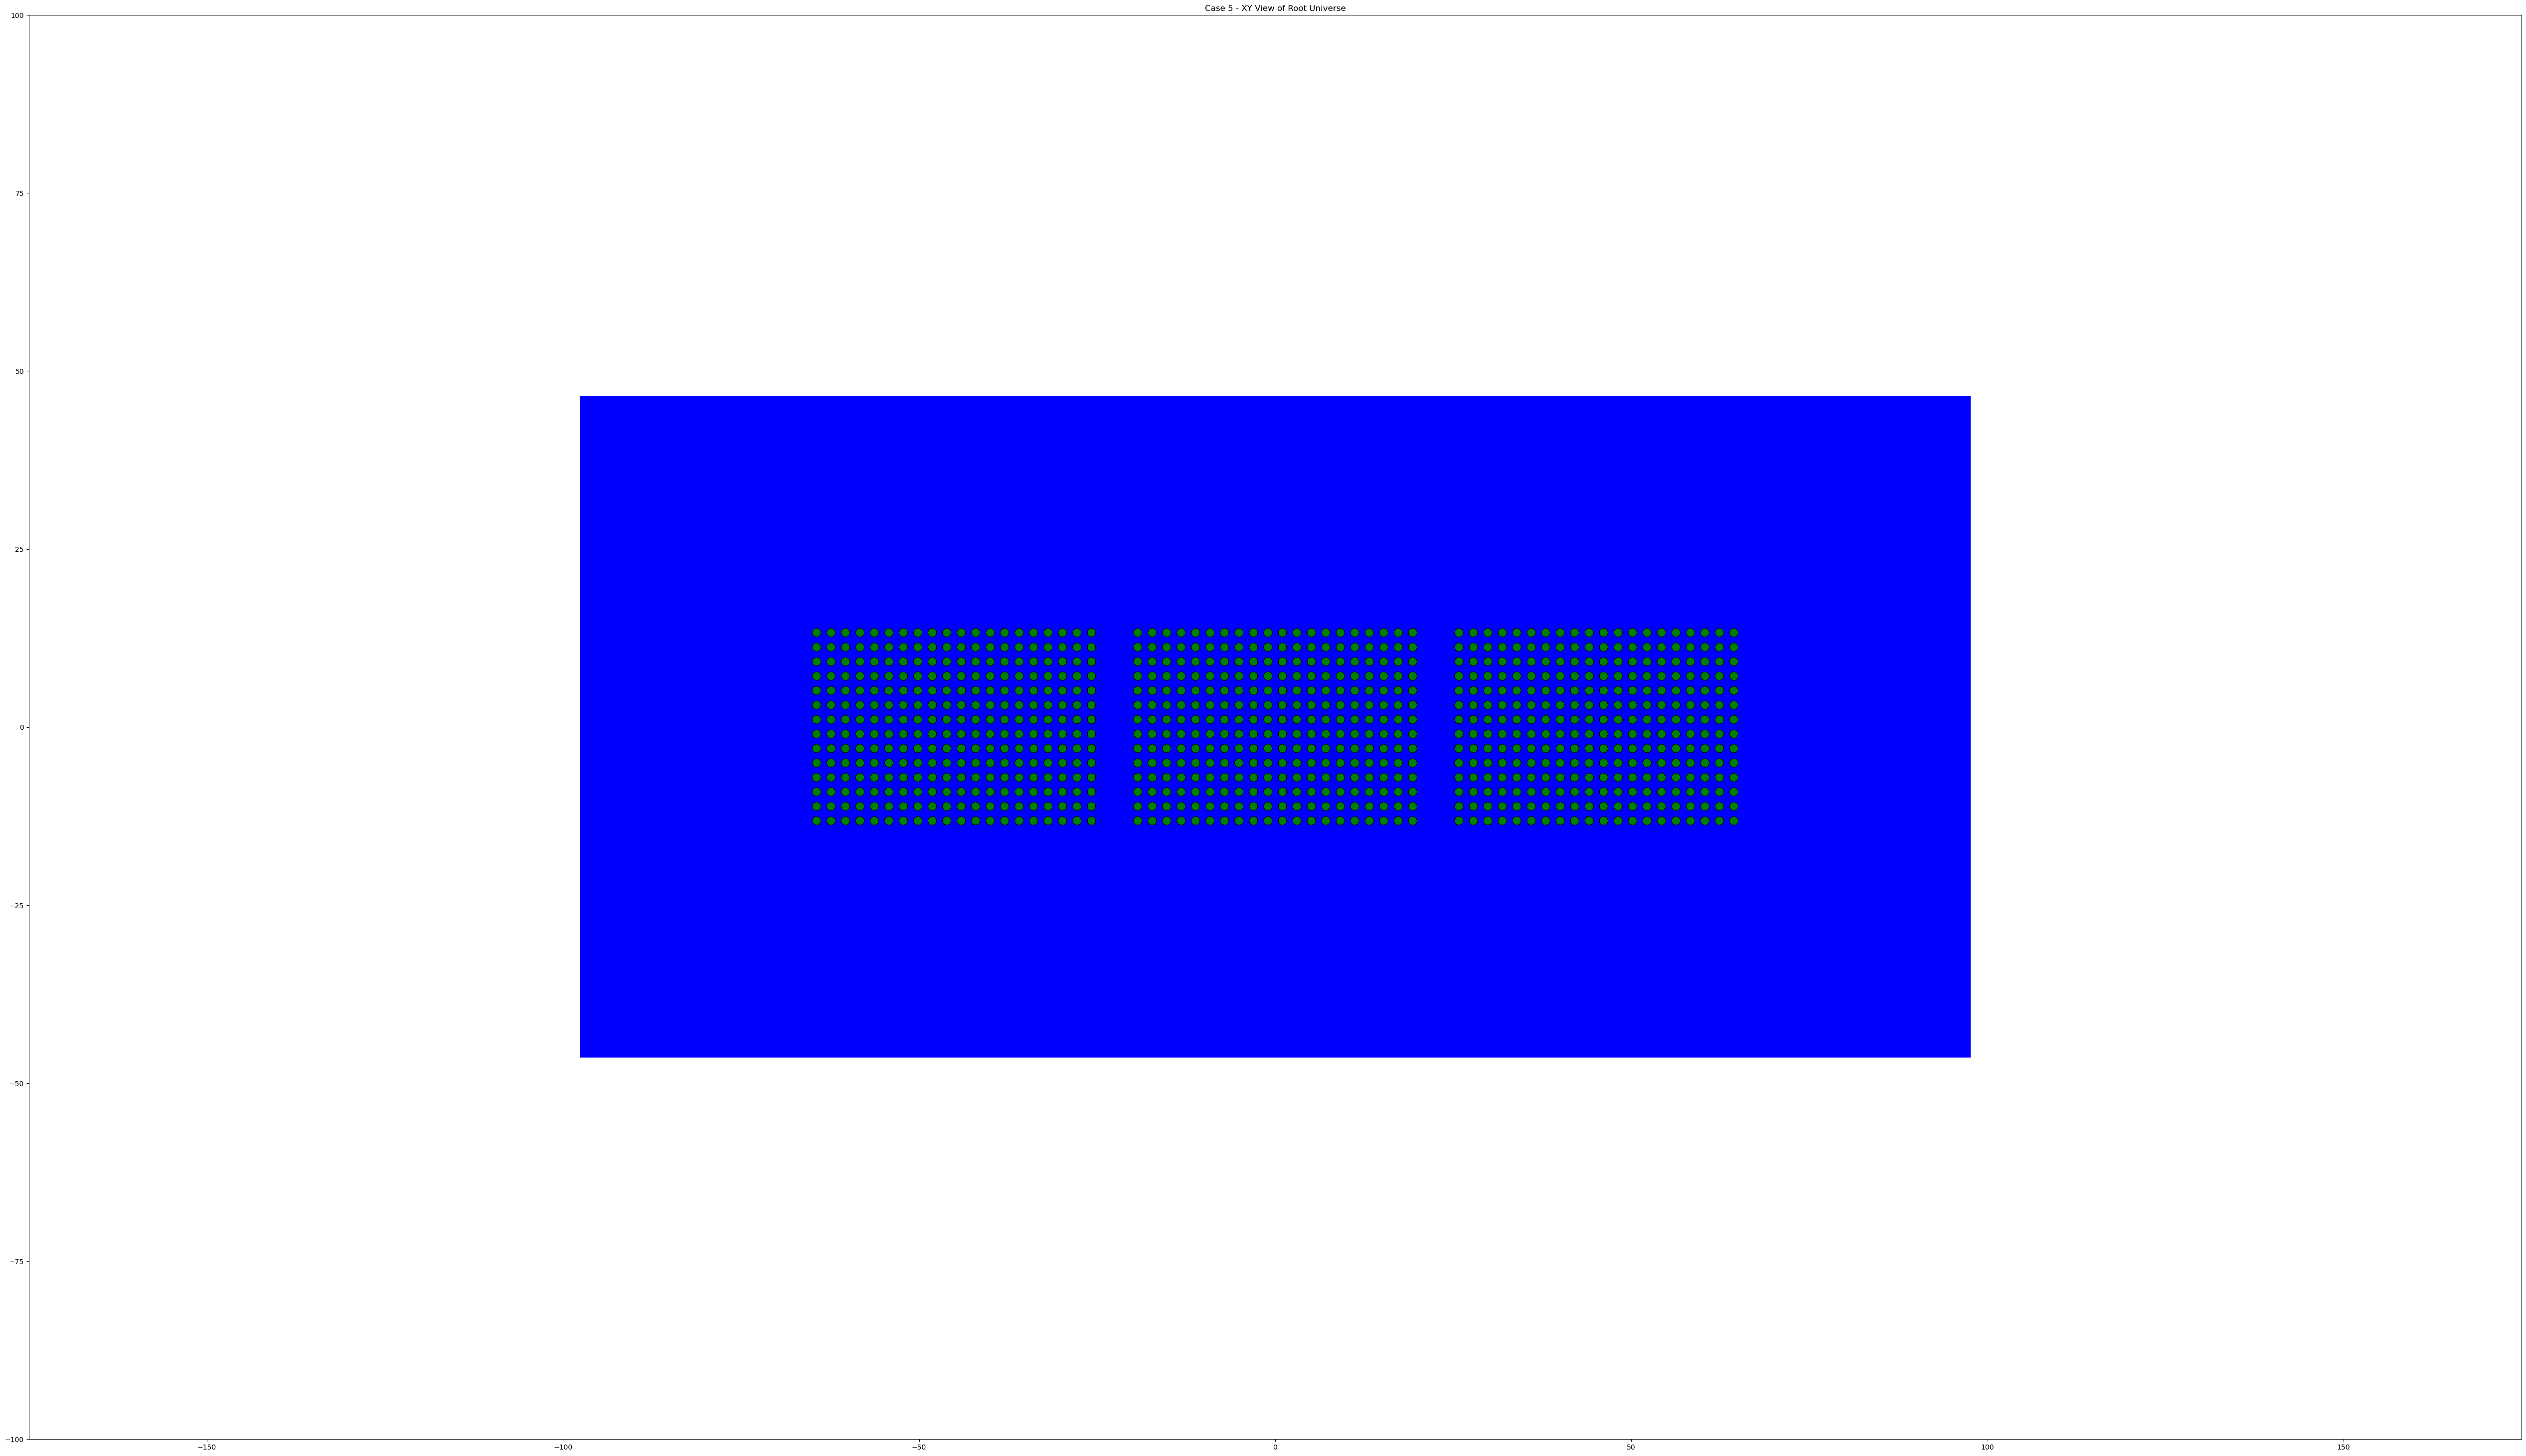

In [9]:
root_universe.plot(origin=(0, 0, 50), basis='xy', width=(350, 200), pixels=[5000, 5000],
                   color_by='material', colors={water: 'blue', uo2_fuel: 'green', Al_6061: 'black', Al_1100: 'pink', Al_5052: 'yellow', acrylic: 'purple'})
plt.title('Case 5 - XY View of Root Universe')
plt.savefig('case5_xy_view.pdf')
plt.show()

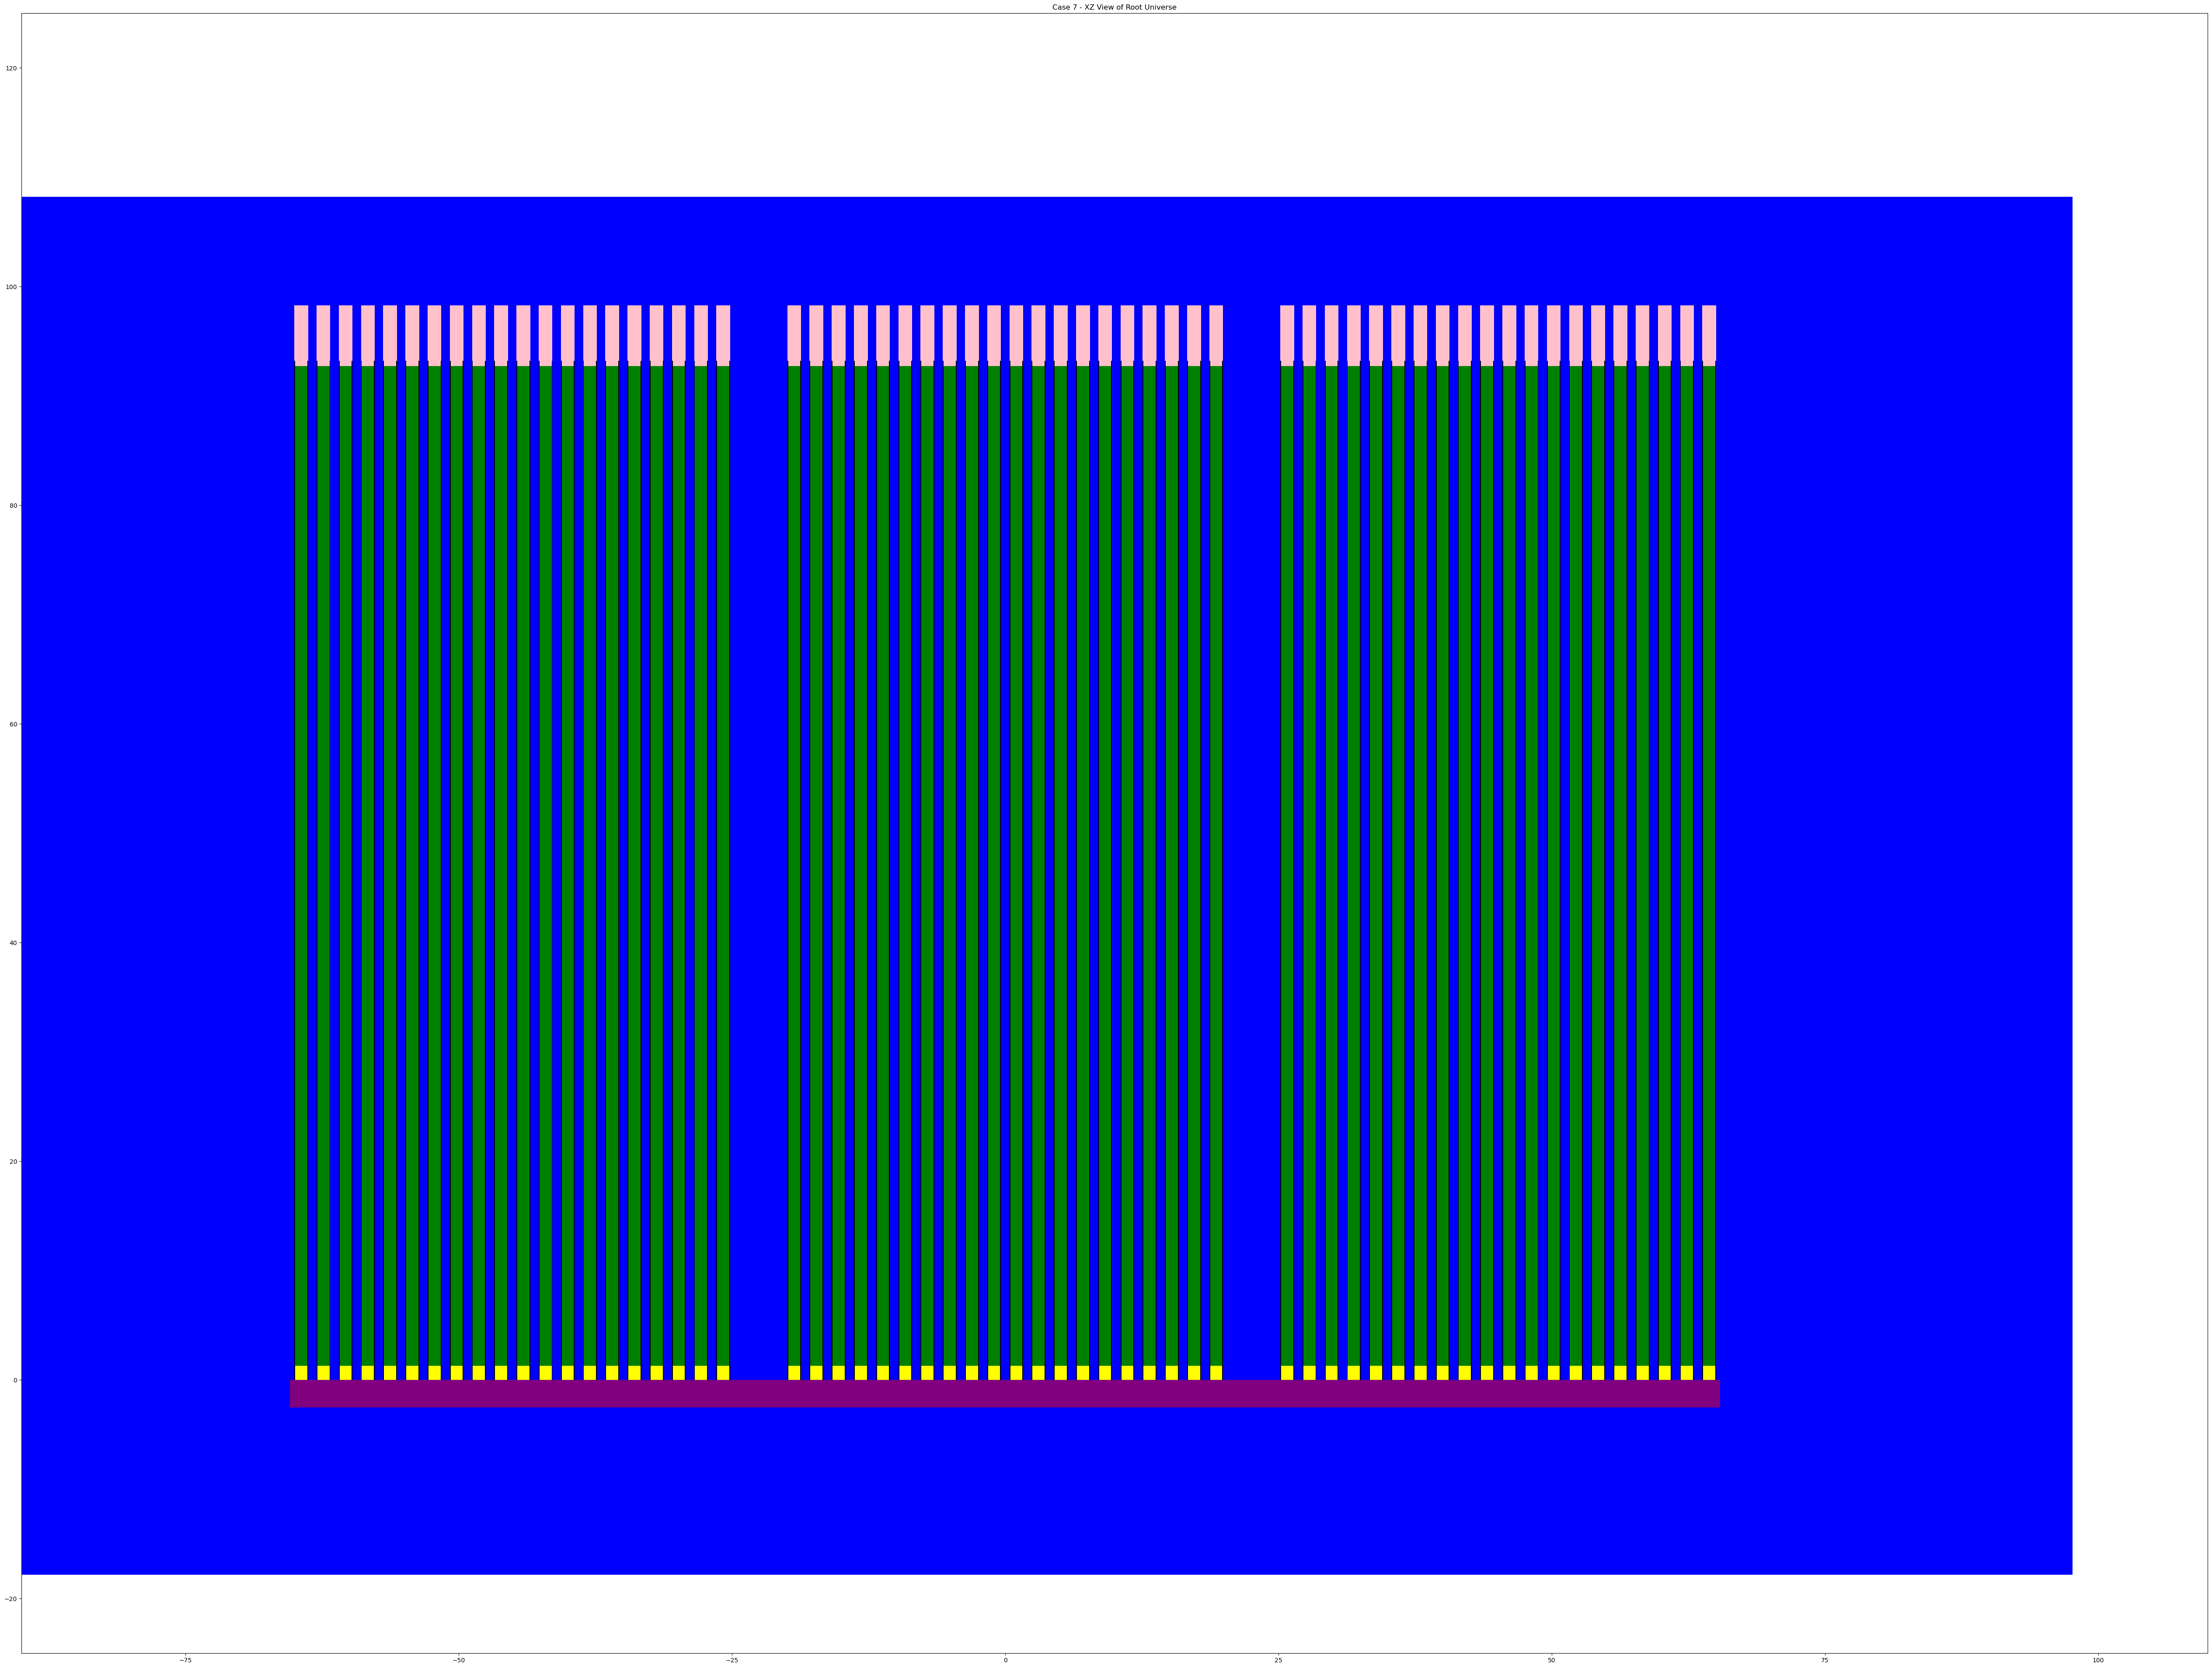

In [14]:
root_universe.plot(origin=(10, 5, 50), basis='xz', width=(200, 150), pixels=[5000, 5000],
                   color_by='material', colors={water: 'blue', uo2_fuel: 'green', Al_6061: 'black', Al_1100: 'pink', Al_5052: 'yellow', acrylic: 'purple'})
plt.title('Case 7 - XZ View of Root Universe')
plt.savefig('case7_xz_view.pdf')
plt.show()

In [15]:
#Source definition

source = openmc.Source()
source.space = openmc.stats.Box(
    lower_left=(-Case7_x_axis / 2, -Case7_y_axis / 2, 1.27),
    upper_right=(Case7_x_axis / 2, Case7_y_axis / 2, 92.71)
)
source.angle = openmc.stats.Isotropic()
source.energy = openmc.stats.Watt(a=988000.0, b=2.249e-06)  # Watt spektrum


#Simulation Settings
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.source = source
settings.batches = 160            # total = inactive + active
settings.inactive = 50
settings.particles = 1500       # (160 - 50) * 455 = 50,050
settings.seed = 123456
settings.export_to_xml()

# Tallies
fuel_tally = openmc.Tally(name="fuel_flux")
fuel_tally.filters = [openmc.CellFilter(fuel_cell)]
fuel_tally.scores = ["flux", "fission", "nu-fission", "heating-local"]  # MCNP F4, F6, F8

tallies = openmc.Tallies([fuel_tally])
tallies.export_to_xml()

openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################